In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file_path=r"country_wise_latest.csv"
df = pd.read_csv(file_path, encoding='unicode_escape')

In [17]:
df.shape

(187, 15)

In [18]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    str    
dtype

In [16]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

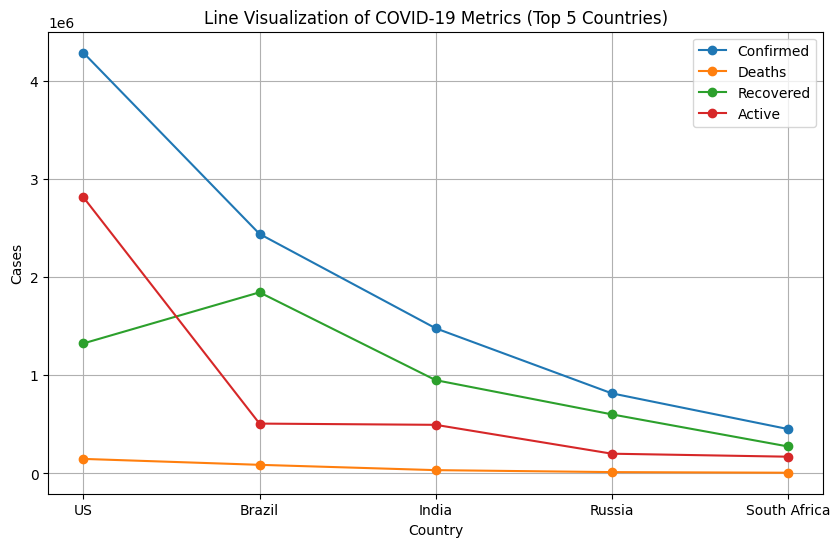

In [20]:
# Line Visualization of COVID-19 Metrics (Top 5 Countries)
top_countries = df.nlargest(5, 'Confirmed')[['Country/Region','Confirmed','Deaths','Recovered','Active']]

plt.figure(figsize=(10,6))

for col in ['Confirmed','Deaths','Recovered','Active']:
    plt.plot(top_countries['Country/Region'], top_countries[col], marker='o', label=col)

plt.xlabel("Country")
plt.ylabel("Cases")
plt.title("Line Visualization of COVID-19 Metrics (Top 5 Countries)")
plt.legend()
plt.grid(True)
plt.show()

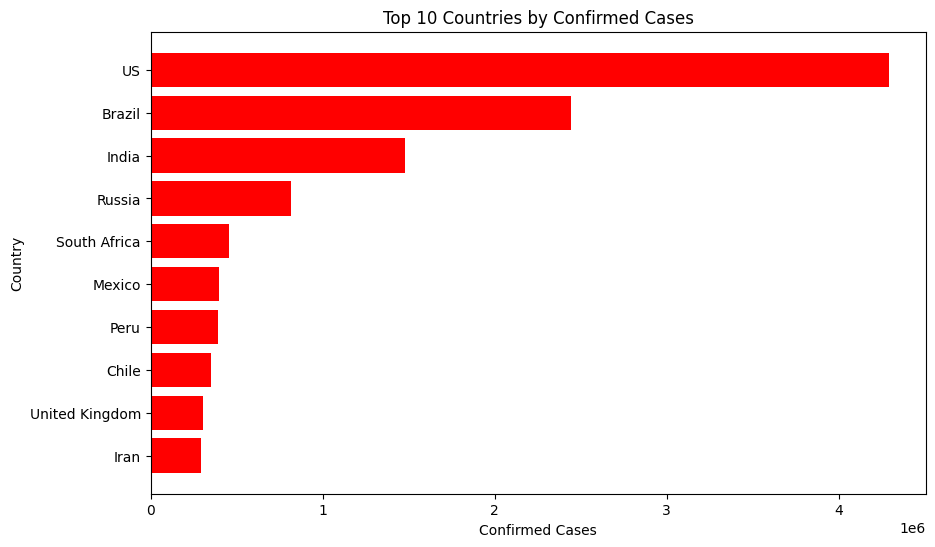

🔹 Country with highest confirmed cases:
Country/Region         US
Confirmed         4290259
Name: 173, dtype: object


In [22]:
# Top 10 countries by confirmed cases highest at top
top_confirmed = df.nlargest(10, 'Confirmed')

plt.figure(figsize=(10,6))
plt.barh(top_confirmed['Country/Region'], top_confirmed['Confirmed'], color='red')
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")
plt.title("Top 10 Countries by Confirmed Cases")
plt.gca().invert_yaxis()  # Highest at top
plt.show()

# Highest confirmed cases
print("🔹 Country with highest confirmed cases:")
print(df.loc[df['Confirmed'].idxmax(), ['Country/Region','Confirmed']])

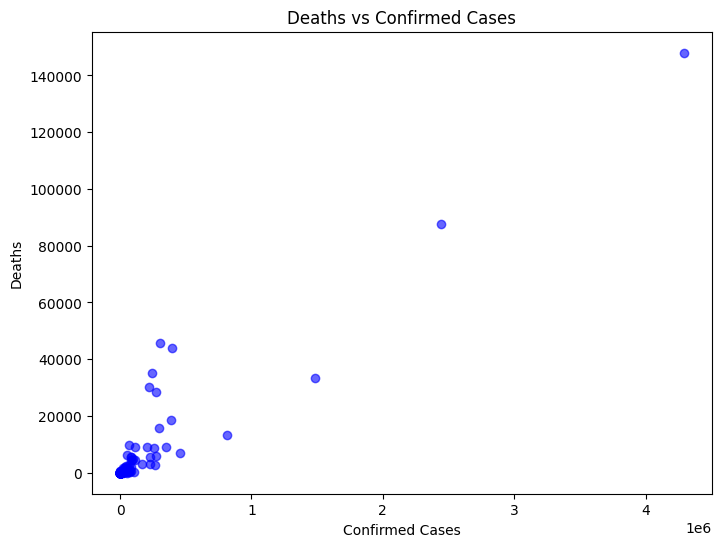


🔹 Country with highest death rate (Deaths per 100 Cases):
Country/Region        Yemen
Deaths / 100 Cases    28.56
Name: 184, dtype: object


In [23]:
# Death vs Confirmed cases
plt.figure(figsize=(8,6))
plt.scatter(df['Confirmed'], df['Deaths'], alpha=0.6, color='blue')
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.title("Deaths vs Confirmed Cases")
plt.show()

# Highest death rate
print("\n🔹 Country with highest death rate (Deaths per 100 Cases):")
print(df.loc[df['Deaths / 100 Cases'].idxmax(), ['Country/Region','Deaths / 100 Cases']])

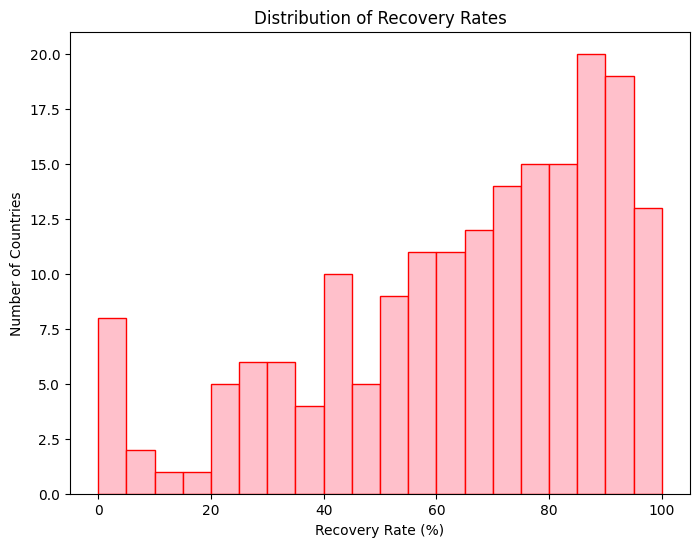


🔹 Average recovery rate by WHO Region:
WHO Region
Western Pacific          76.805000
Europe                   68.635000
South-East Asia          66.704000
Eastern Mediterranean    66.593182
Americas                 62.291429
Africa                   57.014792
Name: Recovered / 100 Cases, dtype: float64


In [24]:
# Distribution of Recovery Rates
plt.figure(figsize=(8,6))
plt.hist(df['Recovered / 100 Cases'], bins=20, color='pink', edgecolor='red')
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Number of Countries")
plt.title("Distribution of Recovery Rates")
plt.show()

# Average recovery rate by WHO Region
print("\n🔹 Average recovery rate by WHO Region:")
print(df.groupby('WHO Region')['Recovered / 100 Cases'].mean().sort_values(ascending=False))

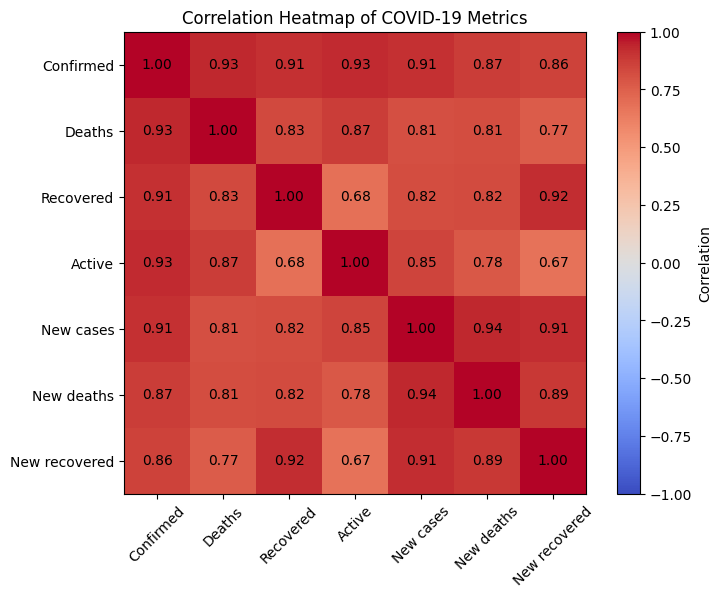

      Metric 1       Metric 2  Correlation
33   New cases     New deaths     0.935947
1    Confirmed         Deaths     0.934698
3    Confirmed         Active     0.927018
20   Recovered  New recovered     0.919203
34   New cases  New recovered     0.914765
4    Confirmed      New cases     0.909720
2    Confirmed      Recovered     0.906377
41  New deaths  New recovered     0.889234
5    Confirmed     New deaths     0.871683
10      Deaths         Active     0.871586


In [9]:
# Correlation Heatmap of COVID-19 Metrics
metrics = ['Confirmed','Deaths','Recovered','Active','New cases','New deaths','New recovered']
corr_matrix = df[metrics].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(metrics)), metrics, rotation=45)
plt.yticks(range(len(metrics)), metrics)
plt.title("Correlation Heatmap of COVID-19 Metrics")

for i in range(len(metrics)):
    for j in range(len(metrics)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.show()


corr_matrix = df[metrics].corr()

# Flatten the matrix into pairs
corr_pairs = (
    corr_matrix.unstack()
    .reset_index()
    .rename(columns={"level_0": "Metric 1", "level_1": "Metric 2", 0: "Correlation"})
)

# Remove self-correlations and duplicate pairs
corr_pairs = corr_pairs[corr_pairs["Metric 1"] != corr_pairs["Metric 2"]]
corr_pairs = corr_pairs.drop_duplicates(subset=["Correlation"])

# Sort by absolute correlation value
top_corr = corr_pairs.reindex(corr_pairs["Correlation"].abs().sort_values(ascending=False).index)

# Select top 10
top_10 = top_corr.head(10)

print(top_10)